### Tableau visualisation


https://public.tableau.com/app/profile/vasyl.kirichuk/viz/Portfolio_17846627926980/Dashboard1?publish=yes

In [ ]:
!pip install --upgrade google-cloud-bigquery

from google.colab import auth
from google.cloud import bigquery
import pandas as pd

# Аутентифікація
auth.authenticate_user()

# Створення клієнта для BigQuery
client = bigquery.Client(project="data-analytics-mate")

# SQL-запит
query = """
SELECT
  s.date AS order_date,
  s.ga_session_id,
  sp.continent,
  sp.country,
  sp.device,
  sp.browser,
  sp.mobile_model_name AS device_model,
  sp.operating_system,
  sp.language AS browser_language,
  sp.name AS traffic_source,
  sp.channel AS traffic_channel,
  a.id AS user_id,
  a.is_verified,
  CASE
    WHEN a.is_unsubscribed IS NULL THEN NULL
    WHEN a.is_unsubscribed = 0 THEN 1
    WHEN a.is_unsubscribed = 1 THEN 0
    END AS is_subscribed,
  p.category,
  p.name AS product_name,
  p.price,
  p.short_description
FROM `data-analytics-mate.DA.session` AS s
INNER JOIN `data-analytics-mate.DA.session_params` AS sp
  ON s.ga_session_id = sp.ga_session_id
LEFT JOIN `data-analytics-mate.DA.order` AS o
  ON s.ga_session_id = o.ga_session_id
LEFT JOIN `data-analytics-mate.DA.product` AS p
  ON o.item_id = p.item_id
LEFT JOIN `data-analytics-mate.DA.account_session` AS acs
  ON s.ga_session_id = acs.ga_session_id
LEFT JOIN `data-analytics-mate.DA.account` AS a
  ON acs.account_id = a.id;
"""

# Виконання запиту
query_job = client.query(query)  # Виконання SQL-запиту
results = query_job.result()  # Очікування завершення запиту

# Перетворення результатів на DataFrame
df = results.to_dataframe(create_bqstorage_client=False)

# Виведення результату
df.head()


,order_date,ga_session_id,continent,country,device,browser,device_model,operating_system,browser_language,traffic_source,traffic_channel,user_id,is_verified,is_subscribed,category,product_name,price,short_description
0,2020-11-01,5760483956,Americas,United States,desktop,Chrome,Safari,Macintosh,zh,<Other>,Paid Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
1,2020-11-01,7115337200,Europe,United Kingdom,desktop,Chrome,Chrome,Web,en-us,(organic),Organic Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
2,2020-11-01,3978035233,Europe,Norway,mobile,Chrome,<Other>,Web,zh,(direct),Direct,<NA>,<NA>,<NA>,Tables & desks,RÅSKOG,189.0,"Trolley, 35x45x78 cm"
3,2020-11-01,9648986282,Africa,Nigeria,mobile,Chrome,<Other>,Android,es-es,(direct),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
4,2020-11-01,4393441533,Asia,China,desktop,Chrome,Chrome,Windows,en-us,(direct),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"


In [ ]:
df.to_csv('portfolio_dataset.csv', index=False)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df.to_csv('/content/drive/MyDrive/Portfolio/portfolio_dataset.csv',index=False)

### Save a local copy of the dataset for reproducibility and offline analysis.

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Portfolio/portfolio_dataset.csv')

In [ ]:
df.head()

,order_date,ga_session_id,continent,country,device,browser,device_model,operating_system,browser_language,traffic_source,traffic_channel,user_id,is_verified,is_subscribed,category,product_name,price,short_description
0,2020-11-01,5760483956,Americas,United States,desktop,Chrome,Safari,Macintosh,zh,<Other>,Paid Search,NaN,NaN,NaN,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
1,2020-11-01,7115337200,Europe,United Kingdom,desktop,Chrome,Chrome,Web,en-us,(organic),Organic Search,NaN,NaN,NaN,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
2,2020-11-01,3978035233,Europe,Norway,mobile,Chrome,<Other>,Web,zh,(direct),Direct,NaN,NaN,NaN,Tables & desks,RÅSKOG,189.0,"Trolley, 35x45x78 cm"
3,2020-11-01,9648986282,Africa,Nigeria,mobile,Chrome,<Other>,Android,es-es,(direct),Direct,NaN,NaN,NaN,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
4,2020-11-01,4393441533,Asia,China,desktop,Chrome,Chrome,Windows,en-us,(direct),Direct,NaN,NaN,NaN,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   order_date         349545 non-null  object 
 1   ga_session_id      349545 non-null  int64  
 2   continent          349545 non-null  object 
 3   country            349545 non-null  object 
 4   device             349545 non-null  object 
 5   browser            349545 non-null  object 
 6   device_model       349545 non-null  object 
 7   operating_system   349545 non-null  object 
 8   browser_language   235279 non-null  object 
 9   traffic_source     349545 non-null  object 
 10  traffic_channel    349545 non-null  object 
 11  user_id            27945 non-null   float64
 12  is_verified        27945 non-null   float64
 13  is_subscribed      27945 non-null   float64
 14  category           33538 non-null   object 
 15  product_name       33538 non-null   object 
 16  pr

In [ ]:
df.describe()

,ga_session_id,user_id,is_verified,is_subscribed,price
count,3.495450e+05,27945.000000,27945.000000,27945.000000,33538.000000
mean,4.992250e+09,659005.065557,0.716980,0.830560,953.298679
std,2.887451e+09,13216.529465,0.450474,0.375147,1317.001775
min,1.205000e+03,636133.000000,0.000000,0.000000,3.000000
25%,2.493647e+09,647576.000000,0.000000,1.000000,170.000000
50%,4.988476e+09,658952.000000,1.000000,1.000000,445.000000
75%,7.491287e+09,670414.000000,1.000000,1.000000,1195.000000
max,9.999997e+09,681962.000000,1.000000,1.000000,9585.000000


In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   order_date         349545 non-null  datetime64[ns]
 1   ga_session_id      349545 non-null  int64         
 2   continent          349545 non-null  object        
 3   country            349545 non-null  object        
 4   device             349545 non-null  object        
 5   browser            349545 non-null  object        
 6   device_model       349545 non-null  object        
 7   operating_system   349545 non-null  object        
 8   browser_language   235279 non-null  object        
 9   traffic_source     349545 non-null  object        
 10  traffic_channel    349545 non-null  object        
 11  user_id            27945 non-null   float64       
 12  is_verified        27945 non-null   float64       
 13  is_subscribed      27945 non-null   float64 

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isna().sum()

,0
order_date,0
ga_session_id,0
continent,0
country,0
device,0
browser,0
device_model,0
operating_system,0
browser_language,114266
traffic_source,0


In [ ]:
df['browser_language'].value_counts(dropna=False)

,count
browser_language,
en-us,159893
NaN,114266
en-gb,24774
zh,12222
en,11518
en-ca,9332
es-es,5760
fr,5652
de,3387


In [ ]:
df['order_date'].min(), df['order_date'].max()

(Timestamp('2020-11-01 00:00:00'), Timestamp('2021-01-31 00:00:00'))

In [ ]:
df['ga_session_id'].nunique()

349545

## **Dataset & Data Quality Summary**

### The dataset contains **349,545** website sessions collected between 1 November 2020 and 31 January 2021. It consists of **18 columns**, including 1 datetime column (order_date), 4 numeric columns (ga_session_id, user_id, is_verified, and is_subscribed), and 12 categorical columns describing user sessions, geographic information, traffic acquisition, devices, browsers, and product information.

### The dataset contains **349,545** unique session IDs, indicating that each row represents a single website session. No duplicate records were found.

### Missing values are present in eight columns. The highest number of missing values is found in user_id, is_verified, and is_subscribed (**321,600** missing values each), followed by category, product_name, price, and short_description (**316,007** missing values each). The browser_language column contains **114,266** missing values.

### The majority of missing values are found in the account-related columns (user_id, is_verified, and is_subscribed). This is expected because the majority of website sessions belong to guest users who do not have registered accounts. As a result, account-related information is not available for these sessions.

### Product-related columns (category, product_name, price, and short_description) contain missing values because many sessions did not result in a purchase. These fields are only populated when a purchase occurs.

### Therefore, no rows were removed and no missing values were imputed, as these missing values represent expected business scenarios rather than data quality issues. The dataset is suitable for further exploratory data analysis, statistical analysis, and dashboard development.

### Data validation confirmed that every order in the analyzed dataset is linked to a unique session. Since the dataset does not contain product quantity, revenue, or profit fields, and each order corresponds to a single session, the price column is used as the sales amount throughout the analysis.

# **Exploratory Data Analysis**

### This section explores the dataset to answer key business questions related to sales performance, customer behavior, traffic acquisition, and device usage. The analysis is based on descriptive statistics and visualizations to identify the main business insights.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import (
    shapiro,
    normaltest,
    ttest_ind,
    mannwhitneyu,
    f_oneway,
    kruskal,
    chi2_contingency,
    pearsonr,
    spearmanr,
    kendalltau
)
from statsmodels.stats.proportion import proportions_ztest

In [ ]:
plt.style.use('fivethirtyeight')

In [ ]:
continent_summary = (df.groupby('continent', dropna=False).agg(Sales=('price', 'sum'),Orders=('ga_session_id', 'count')).sort_values('Sales', ascending=False).head(3).reset_index())

continent_summary

,continent,Sales,Orders
0,Americas,17665280.0,193179
1,Asia,7601298.3,83113
2,Europe,5934624.2,65135


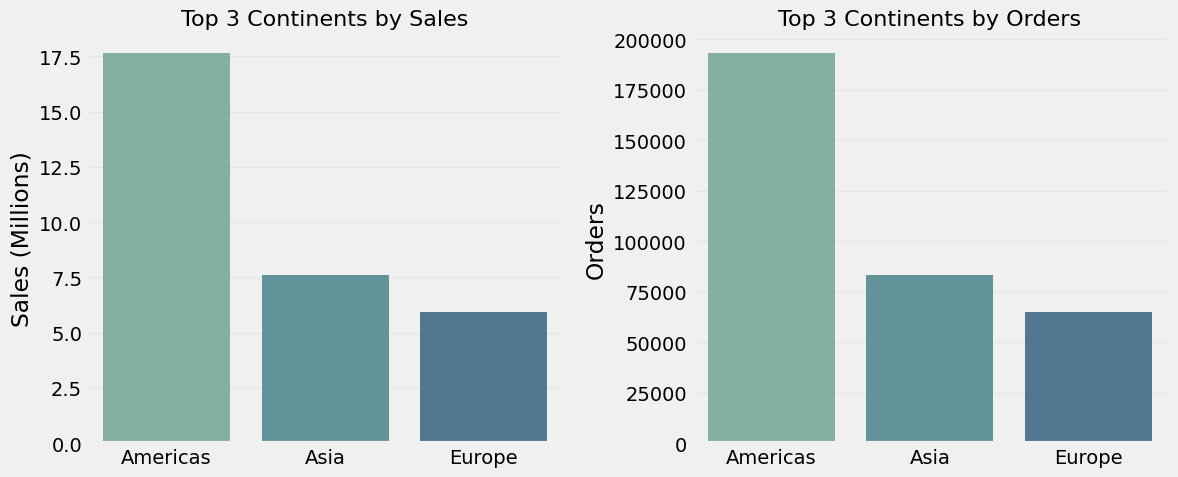

In [ ]:
continent_summary['Sales_M'] = continent_summary['Sales'] / 1_000_000

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=continent_summary, x='continent', y='Sales_M', hue='continent', palette='crest', legend=False, ax=axes[0], alpha=0.8)
axes[0].set_title('Top 3 Continents by Sales', fontsize=16)
axes[0].set_xlabel('')
axes[0].set_ylabel('Sales (Millions)')
axes[0].grid(axis='y', alpha=0.25)

sns.barplot(data=continent_summary, x='continent', y='Orders', hue='continent', palette='crest', legend=False, ax=axes[1], alpha=0.8)
axes[1].set_title('Top 3 Continents by Orders', fontsize=16)
axes[1].set_xlabel('')
axes[1].set_ylabel('Orders')
axes[1].grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

In [ ]:
country_summary = df.groupby('country', dropna=False).agg(Sales=('price', 'sum'), Orders=('ga_session_id', 'count')).sort_values('Sales', ascending=False).head(5).reset_index()

country_summary['Sales_M'] = country_summary['Sales'] / 1_000_000

country_summary

,country,Sales,Orders,Sales_M
0,United States,13943553.9,153470,13.943554
1,India,2809762.0,32763,2.809762
2,Canada,2437921.0,25994,2.437921
3,United Kingdom,938317.9,11003,0.938318
4,France,710692.8,6958,0.710693


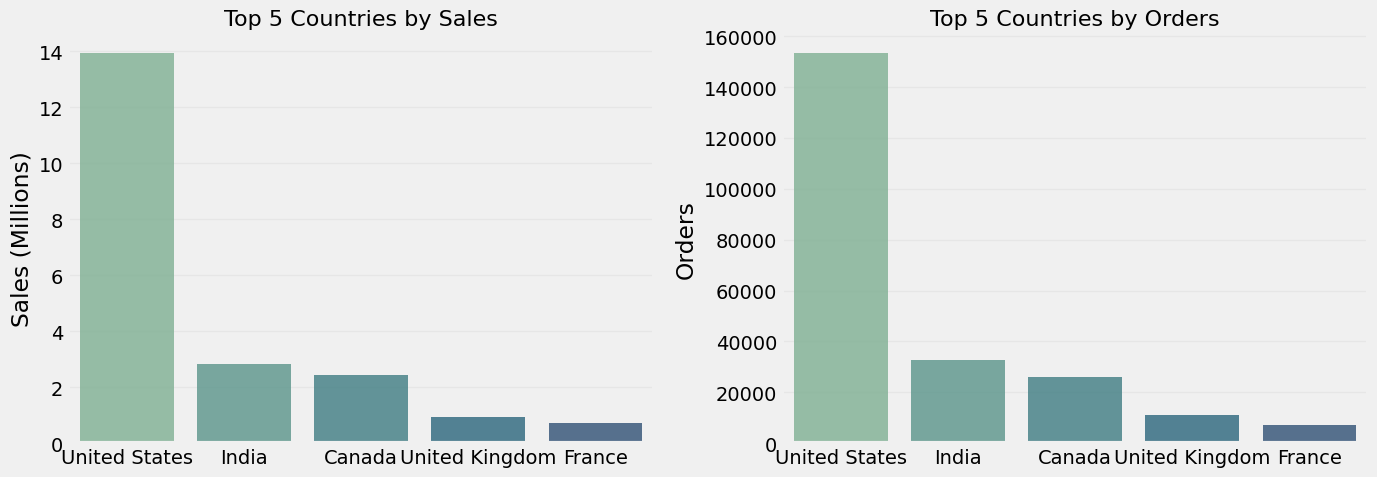

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=country_summary, x='country', y='Sales_M', hue='country', palette='crest', legend=False, ax=axes[0], alpha=0.8)
axes[0].set_title('Top 5 Countries by Sales', fontsize=16)
axes[0].set_xlabel('')
axes[0].set_ylabel('Sales (Millions)')
axes[0].grid(axis='y', alpha=0.25)

sns.barplot(data=country_summary, x='country', y='Orders', hue='country', palette='crest', legend=False, ax=axes[1], alpha=0.8)
axes[1].set_title('Top 5 Countries by Orders', fontsize=16)
axes[1].set_xlabel('')
axes[1].set_ylabel('Orders')
axes[1].grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

In [ ]:
country_sales = df.groupby('country').agg(Sales=('price', 'sum')).sort_values('Sales', ascending=False).reset_index()

country_sales

,country,Sales
0,United States,13943553.9
1,India,2809762.0
2,Canada,2437921.0
3,United Kingdom,938317.9
4,France,710692.8
...,...,...
103,Bahamas,2411.0
104,Guatemala,2259.0
105,Ghana,1018.0
106,Bosnia & Herzegovina,939.0


In [ ]:
category_summary = df.groupby('category').agg(Sales=('price', 'sum')).sort_values('Sales', ascending=False).head(10).reset_index()

category_summary['Sales_M'] = category_summary['Sales'] / 1_000_000

category_summary

,category,Sales,Sales_M
0,Sofas & armchairs,8388254.5,8.388255
1,Chairs,6147748.8,6.147749
2,Beds,4919725.0,4.919725
3,Bookcases & shelving units,3640818.1,3.640818
4,Cabinets & cupboards,2336499.5,2.336499
5,Outdoor furniture,2142222.2,2.142222
6,Tables & desks,1790307.5,1.790307
7,Chests of drawers & drawer units,906562.5,0.906563
8,Bar furniture,735503.0,0.735503
9,Children's furniture,467697.0,0.467697


In [ ]:
top_country = country_sales.loc[0, 'country']

top_country

'United States'

In [ ]:
top_country_df = df[df['country'] == top_country]

top_country_df

,order_date,ga_session_id,continent,country,device,browser,device_model,operating_system,browser_language,traffic_source,traffic_channel,user_id,is_verified,is_subscribed,category,product_name,price,short_description
0,2020-11-01,5760483956,Americas,United States,desktop,Chrome,Safari,Macintosh,zh,<Other>,Paid Search,NaN,NaN,NaN,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
5,2020-11-01,967742695,Americas,United States,desktop,Safari,Safari,Web,en-us,(data deleted),Undefined,NaN,NaN,NaN,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
9,2020-11-01,1129172264,Americas,United States,mobile,Chrome,<Other>,Android,en-us,(direct),Direct,NaN,NaN,NaN,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
14,2020-11-01,7736972530,Americas,United States,mobile,Safari,iPhone,Web,NaN,(referral),Paid Search,NaN,NaN,NaN,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
15,2020-11-01,3267062634,Americas,United States,desktop,Chrome,Safari,Web,en-us,(data deleted),Undefined,NaN,NaN,NaN,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
349534,2021-01-31,2531253331,Americas,United States,desktop,Chrome,Safari,Web,en-us,<Other>,Organic Search,NaN,NaN,NaN,NaN,NaN,NaN,NaN
349537,2021-01-31,1587098569,Americas,United States,mobile,Chrome,<Other>,Web,NaN,(referral),Social Search,NaN,NaN,NaN,NaN,NaN,NaN,NaN
349538,2021-01-31,3237997913,Americas,United States,mobile,Chrome,<Other>,Android,NaN,(direct),Direct,NaN,NaN,NaN,NaN,NaN,NaN,NaN
349541,2021-01-31,464560636,Americas,United States,desktop,Edge,Edge,Web,en-us,(organic),Organic Search,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
top_country_categories = top_country_df.groupby('category').agg(Sales=('price', 'sum')).sort_values('Sales', ascending=False).head(10).reset_index()

top_country_categories['Sales_M'] = top_country_categories['Sales'] / 1_000_000

top_country_categories

,category,Sales,Sales_M
0,Sofas & armchairs,3707144.5,3.707145
1,Chairs,2619773.8,2.619774
2,Beds,2213058.0,2.213058
3,Bookcases & shelving units,1567606.9,1.567607
4,Cabinets & cupboards,994545.5,0.994545
5,Outdoor furniture,929245.2,0.929245
6,Tables & desks,777865.0,0.777865
7,Chests of drawers & drawer units,382388.0,0.382388
8,Bar furniture,330805.0,0.330805
9,Children's furniture,207575.0,0.207575


### The top-selling product categories in the highest-selling country closely match the overall ranking. No substantial differences in category preferences were observed.

In [ ]:
device_type_summary = df.groupby('device').agg(Sales=('price', 'sum')).sort_values('Sales', ascending=False).reset_index()

device_type_summary['Sales_%'] = round(device_type_summary['Sales'] / device_type_summary['Sales'].sum() * 100, 2)

device_type_summary

,device,Sales,Sales_%
0,desktop,18864039.0,59.00
1,mobile,12384225.8,38.73
2,tablet,723466.3,2.26


In [ ]:
device_model_summary = df.groupby('device_model').agg(Sales=('price', 'sum')).sort_values('Sales', ascending=False).head(10).reset_index()

device_model_summary['Sales_%'] = round(device_model_summary['Sales'] / df['price'].sum() * 100, 2)

device_model_summary

,device_model,Sales,Sales_%
0,Chrome,8899523.9,27.84
1,<Other>,6535330.8,20.44
2,Safari,6491062.1,20.30
3,iPhone,6420776.3,20.08
4,ChromeBook,1830458.7,5.73
5,Edge,697222.3,2.18
6,iPad,448854.2,1.40
7,Firefox,421066.9,1.32
8,Pixel 4 XL,118287.7,0.37
9,Pixel 3,109148.2,0.34


In [ ]:
traffic_source_summary = df.groupby('traffic_source').agg(Sales=('price', 'sum')).sort_values('Sales', ascending=False).reset_index()

traffic_source_summary['Sales_%'] = round(traffic_source_summary['Sales'] / traffic_source_summary['Sales'].sum() * 100, 2)

traffic_source_summary

,traffic_source,Sales,Sales_%
0,(organic),10935239.9,34.20
1,(direct),7494923.4,23.44
2,<Other>,5897375.6,18.45
3,(referral),5641855.2,17.65
4,(data deleted),2002337.0,6.26


### Desktop devices accounted for the largest share of total sales (59.0%), indicating that most purchases were completed on desktop devices. Organic search was the leading traffic source, generating 34.2% of total sales, followed by direct and referral traffic.

In [ ]:
registered_users = df[df['user_id'].notna()]

In [ ]:
verified_summary = registered_users['is_verified'].value_counts(dropna=False).reset_index()
verified_summary.columns = ['Verified', 'Users']
verified_summary['Percentage'] = round(verified_summary['Users'] / verified_summary['Users'].sum() * 100, 2)

verified_summary

,Verified,Users,Percentage
0,1.0,20036,71.7
1,0.0,7909,28.3


In [ ]:
subscription_summary = registered_users['is_subscribed'].value_counts(dropna=False).reset_index()
subscription_summary.columns = ['Subscribed', 'Users']
subscription_summary['Percentage'] = round(subscription_summary['Users'] / subscription_summary['Users'].sum() * 100, 2)

subscription_summary

,Subscribed,Users,Percentage
0,1.0,23210,83.06
1,0.0,4735,16.94


In [ ]:
subscription_sales = registered_users.groupby('is_subscribed').agg(Sales=('price', 'sum'), Orders=('ga_session_id', 'count')).reset_index()

subscription_sales['Sales_M'] = subscription_sales['Sales'] / 1_000_000

subscription_sales

,is_subscribed,Sales,Orders,Sales_M
0,0.0,431721.6,4735,0.431722
1,1.0,2150796.9,23210,2.150797


In [ ]:
subscription_sales = registered_users.groupby('is_subscribed').agg(Sales=('price', 'sum'), Orders=('ga_session_id', 'count')).reset_index()

subscription_sales['Sales_M'] = subscription_sales['Sales'] / 1_000_000
subscription_sales['Average_Sales'] = round(subscription_sales['Sales'] / subscription_sales['Orders'], 2)

subscription_sales

,is_subscribed,Sales,Orders,Sales_M,Average_Sales
0,0.0,431721.6,4735,0.431722,91.18
1,1.0,2150796.9,23210,2.150797,92.67


### Subscribed users generated a higher total sales volume because this group is substantially larger. However, the average sales per order are very similar (92.67 vs. 91.18), indicating no meaningful difference in purchasing behavior between subscribed and unsubscribed users.

In [ ]:
registered_by_country = registered_users.groupby('country').agg(Registered_Users=('user_id', 'count')).sort_values('Registered_Users', ascending=False).head(10).reset_index()

registered_by_country

,country,Registered_Users
0,United States,12384
1,India,2687
2,Canada,2067
3,United Kingdom,859
4,France,553
5,Spain,536
6,Taiwan,500
7,China,490
8,Germany,490
9,Italy,386


/tmp/ipykernel_1739/179240911.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=registered_by_country, x='country', y='Registered_Users', alpha=0.8, palette='crest')


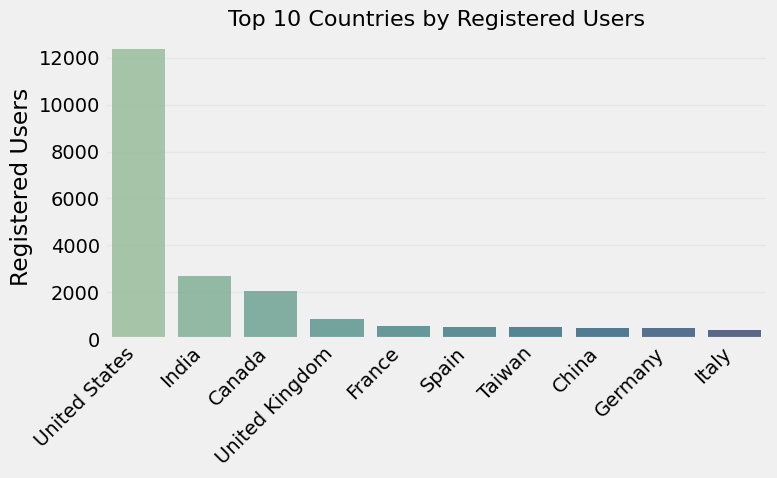

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(data=registered_by_country, x='country', y='Registered_Users', alpha=0.8, palette='crest')

ax.set_title('Top 10 Countries by Registered Users', fontsize=16)
ax.set_xlabel('')
ax.set_ylabel('Registered Users')
ax.grid(axis='y', alpha=0.25)

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### The United States has by far the largest number of registered users, followed by India and Canada. User registration is highly concentrated in a small number of countries, indicating that the company's registered customer base is driven primarily by a few key markets.

In [ ]:
aov = df[df['traffic_channel'].isin(['Organic Search', 'Paid Search'])].groupby('traffic_channel').agg(Orders=('price', 'count'), Total_Revenue=('price', 'sum'), Average_Order_Value=('price', 'mean')).round(2)

aov

,Orders,Total_Revenue,Average_Order_Value
traffic_channel,,,
Organic Search,11921,11433151.6,959.08
Paid Search,9042,8511049.4,941.28


### Calculate the Average Order Value (AOV) for Organic Search and Paid Search traffic channels to compare which channel generates higher-value orders.

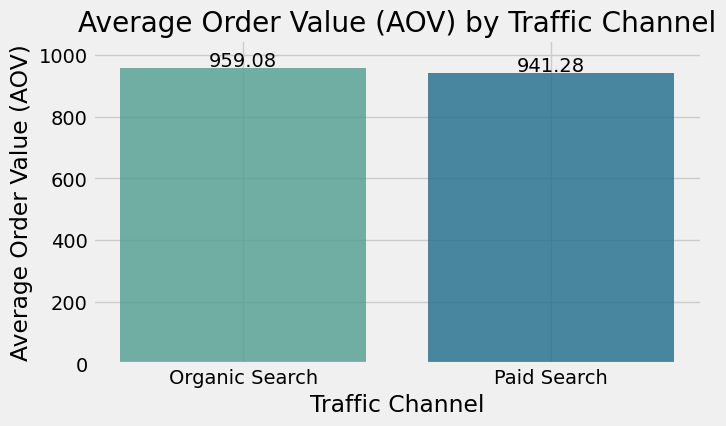

In [ ]:
plt.figure(figsize=(7, 4))

bars = plt.bar(aov.index, aov['Average_Order_Value'], color=sns.color_palette('crest', len(aov)), alpha=0.8)

plt.title('Average Order Value (AOV) by Traffic Channel')
plt.xlabel('Traffic Channel')
plt.ylabel('Average Order Value (AOV)')

for bar in bars:plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5, f'{bar.get_height():.2f}', ha='center')
plt.ylim(0, 1050)

plt.show()

### **Business Conclusion**

#### Organic Search generated a higher number of orders and a slightly higher Average Order Value (959.08) than Paid Search (941.28). Based on these descriptive results, customers acquired through Organic Search tend to place slightly higher-value orders. However, further statistical testing is required to determine whether this difference is statistically significant.

In [ ]:
conversion = df.groupby('traffic_channel').agg(Sessions=('ga_session_id', 'nunique'), Purchases=('price', 'count'))
conversion['Conversion_Rate (%)'] = (conversion['Purchases'] / conversion['Sessions'] * 100).round(2)

conversion.sort_values('Conversion_Rate (%)', ascending=False)

,Sessions,Purchases,Conversion_Rate (%)
traffic_channel,,,
Social Search,27914,2716,9.73
Direct,81382,7800,9.58
Organic Search,124425,11921,9.58
Paid Search,94341,9042,9.58
Undefined,21483,2059,9.58


### Calculate the session-to-purchase conversion rate for each traffic channel to identify which channel converts visitors into customers most effectively.

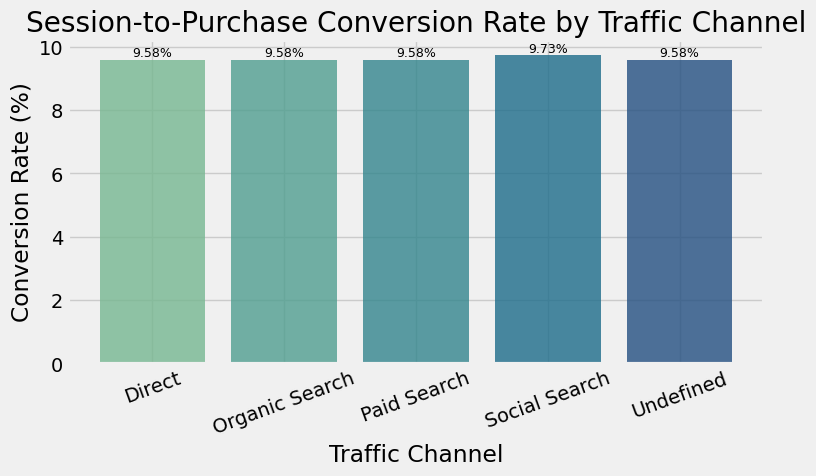

In [ ]:
plt.figure(figsize=(8, 4))

bars = plt.bar(conversion.index, conversion['Conversion_Rate (%)'], color=sns.color_palette('crest', n_colors=len(conversion)), alpha=0.8)

plt.title('Session-to-Purchase Conversion Rate by Traffic Channel')
plt.xlabel('Traffic Channel')
plt.ylabel('Conversion Rate (%)')
plt.xticks(rotation=20)

for bar in bars:plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{bar.get_height():.2f}%', ha='center', fontsize=9)

plt.show()

### **Business Conclusion**

#### The session-to-purchase conversion rate is remarkably consistent across all traffic channels, remaining close to 9.6%. Social Search achieved the highest conversion rate (9.73%), although the difference compared to other channels is minimal. Overall, the results indicate that all traffic channels perform similarly in converting sessions into purchases.

# **Sales Trend Analysis**
### In this section, we analyze how sales changed over time. We examine overall sales dynamics, compare trends across continents, traffic channels, and device types, and identify patterns that may indicate seasonality or changes in customer behavior.

### The chart does not provide sufficient evidence of a clear seasonal pattern due to the short three-month observation period. However, sales peaks are visible in December and early January, which may be associated with holiday shopping.

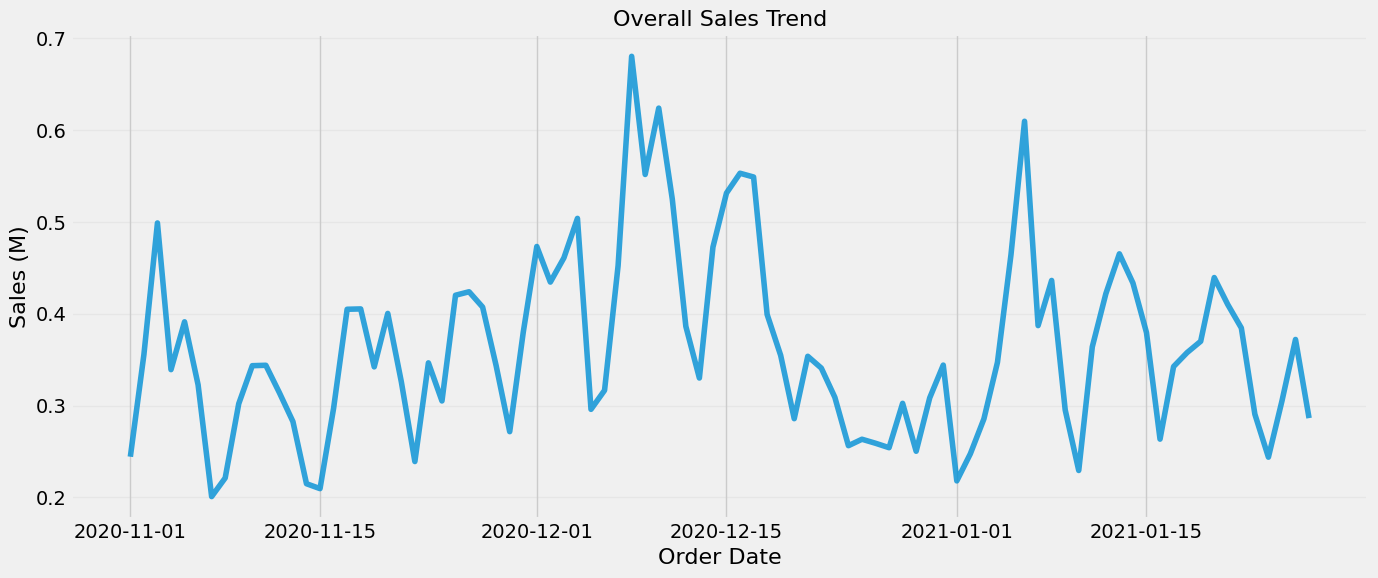

In [ ]:
sales_trend = df.groupby('order_date')['price'].sum().reset_index()

sales_trend['Sales_M'] = sales_trend['price'] / 1000000

sales_trend = sales_trend[sales_trend['price'] > 0]

plt.figure(figsize=(14, 6))

sns.lineplot(data=sales_trend, x='order_date', y='Sales_M', alpha=0.8)

plt.title('Overall Sales Trend', fontsize=16)
plt.xlabel('Order Date', fontsize=16)
plt.ylabel('Sales (M)', fontsize=16)

plt.grid(axis='y', alpha=0.25)

plt.tight_layout()

plt.show()

### The chart does not provide sufficient evidence of a clear seasonal pattern due to the short three-month observation period. However, sales peaks are visible in December and early January, which may be associated with holiday shopping.

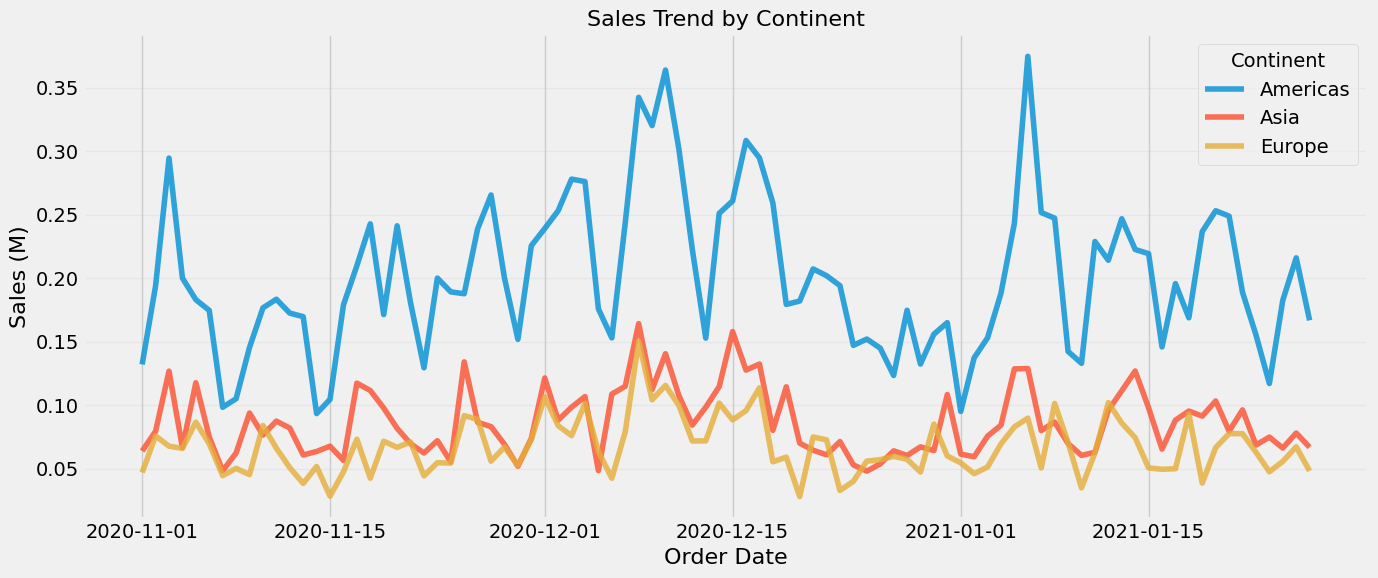

In [ ]:
continent_sales = df[df['continent'].isin(['Americas', 'Europe', 'Asia'])]

continent_sales = continent_sales.groupby(['order_date', 'continent'])['price'].sum().reset_index()

continent_sales['Sales_M'] = continent_sales['price'] / 1000000
continent_sales = continent_sales[continent_sales['price'] > 0]
plt.figure(figsize=(14, 6))

sns.lineplot(data=continent_sales, x='order_date', y='Sales_M', hue='continent', alpha=0.8)

plt.title('Sales Trend by Continent', fontsize=16)
plt.xlabel('Order Date', fontsize=16)
plt.ylabel('Sales (M)', fontsize=16)

plt.grid(axis='y', alpha=0.25)

plt.legend(title='Continent')

plt.tight_layout()

plt.show()

### The Americas consistently generated the highest daily sales throughout the observation period. Asia and Europe followed similar sales patterns with lower volumes. Sales peaks occurred at approximately the same time across all three continents, suggesting common demand fluctuations during the period.

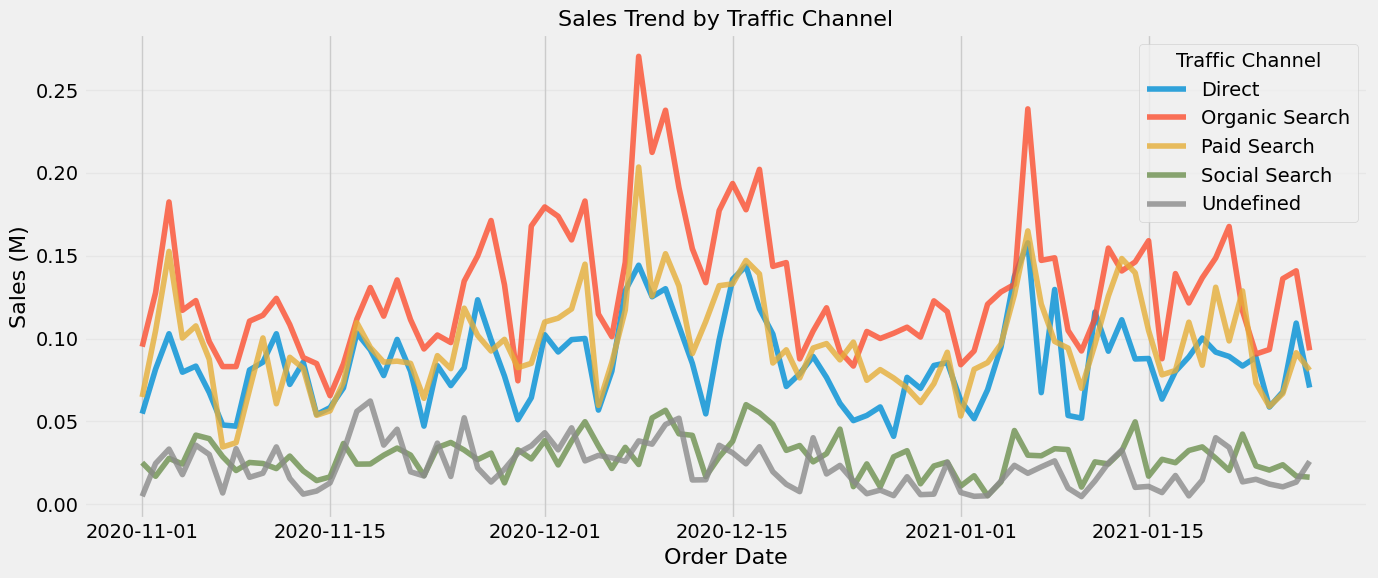

In [ ]:
channel_sales = df.groupby(['order_date', 'traffic_channel'])['price'].sum().reset_index()

channel_sales['Sales_M'] = channel_sales['price'] / 1000000
channel_sales = channel_sales[channel_sales['price'] > 0]
plt.figure(figsize=(14, 6))

sns.lineplot(data=channel_sales, x='order_date', y='Sales_M', hue='traffic_channel', alpha=0.8)

plt.title('Sales Trend by Traffic Channel', fontsize=16)
plt.xlabel('Order Date', fontsize=16)
plt.ylabel('Sales (M)', fontsize=16)

plt.grid(axis='y', alpha=0.25)

plt.legend(title='Traffic Channel')

plt.tight_layout()

plt.show()

### Organic Search consistently generated the highest sales throughout the observation period. Paid Search and Direct followed similar trends with moderate sales volumes, while Social Search and Undefined contributed substantially less to total sales.

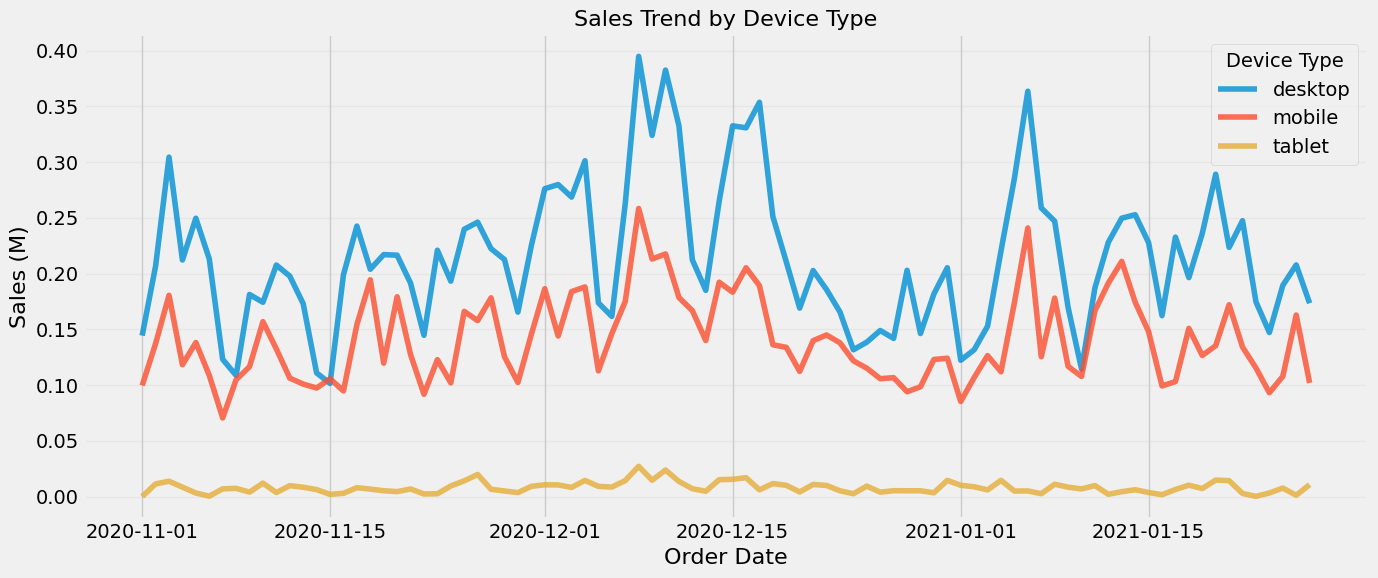

In [ ]:
device_sales = df.groupby(['order_date', 'device'])['price'].sum().reset_index()

device_sales['Sales_M'] = device_sales['price'] / 1000000
device_sales = device_sales[device_sales['price'] > 0]
plt.figure(figsize=(14, 6))

sns.lineplot(data=device_sales, x='order_date', y='Sales_M', hue='device', alpha=0.8)

plt.title('Sales Trend by Device Type', fontsize=16)
plt.xlabel('Order Date', fontsize=16)
plt.ylabel('Sales (M)', fontsize=16)

plt.grid(axis='y', alpha=0.25)

plt.legend(title='Device Type')

plt.tight_layout()

plt.show()

### Desktop had the highest sales throughout the observation period. Mobile was the second-largest sales channel, while Tablet generated the lowest sales. All device types followed a similar sales pattern over time.

In [ ]:
df[df['traffic_channel'] != 'Undefined'].pivot_table(index='traffic_channel', columns='device', values='ga_session_id', aggfunc='nunique')

device,desktop,mobile,tablet
traffic_channel,,,
Direct,47825,31745,1812
Organic Search,72622,49014,2789
Paid Search,55167,37034,2140
Social Search,16288,10988,638


### Organic Search generated the highest number of unique sessions across all device types. Desktop had the highest number of sessions in every traffic channel, while Tablet consistently recorded the fewest sessions.

In [ ]:
top_categories = df.groupby('category')['price'].sum().nlargest(10).index

In [ ]:
top_countries = df.groupby('country')['price'].sum().nlargest(5).index

In [ ]:
df[df['category'].isin(top_categories) & df['country'].isin(top_countries)].pivot_table(index='category', columns='country', values='price', aggfunc='sum')

country,Canada,France,India,United Kingdom,United States
category,,,,,
Bar furniture,51724.0,11199.0,57657.0,22103.0,330805.0
Beds,354772.0,116414.0,358319.5,133816.0,2213058.0
Bookcases & shelving units,278981.9,73830.0,364507.4,113987.6,1567606.9
Cabinets & cupboards,181802.0,59101.5,191888.0,71684.5,994545.5
Chairs,417740.8,134029.4,544309.2,188519.4,2619773.8
Chests of drawers & drawer units,71952.0,21544.5,73111.0,36784.0,382388.0
Children's furniture,30264.0,14258.0,39177.0,13348.0,207575.0
Outdoor furniture,185322.8,40486.4,162289.4,57002.4,929245.2
Sofas & armchairs,692427.5,187735.0,788430.0,234812.0,3707144.5


### The United States generated the highest sales in every top product category. Chairs, Sofas & armchairs, and Beds were among the strongest-performing categories across the top five countries, while Canada and India also showed strong demand for furniture products.

In [ ]:
df[df['traffic_channel'] != 'Undefined'].pivot_table(index='traffic_channel', columns='device', values='price', aggfunc='sum')

device,desktop,mobile,tablet
traffic_channel,,,
Direct,4472609.4,2875317.9,146996.1
Organic Search,6794107.8,4408875.1,230168.7
Paid Search,4976977.8,3330032.6,204039.0
Social Search,1447384.8,1006707.3,78013.6


### Organic Search generated the highest sales across all device types. Desktop consistently produced the highest sales in every traffic channel, while Tablet generated the lowest sales. Paid Search ranked second in sales, followed by Direct and Social Search.

In [ ]:
df.pivot_table(index='browser', columns='device', values='price', aggfunc='sum')

device,desktop,mobile,tablet
browser,,,
<Other>,318000.9,544545.3,60808.6
Android Webview,NaN,392386.4,18628.0
Chrome,15778375.2,5667208.9,381265.9
Edge,716444.3,0.0,NaN
Firefox,535659.6,31864.0,NaN
Safari,1515559.0,5748221.2,262763.8


### Chrome generated the highest sales across all device types, followed by Safari. Since the <Other> category combines multiple browsers, it was not analyzed separately.

# **Correlation Analysis**

### This section explores relationships between key business metrics. Pearson correlation analysis is used to measure the strength of relationships and assess their statistical significance. A correlation heatmap is also included to visualize the correlation matrix.

In [ ]:
daily_data = df.groupby('order_date').agg({'ga_session_id': 'nunique', 'price': 'sum'})
daily_data

,ga_session_id,price
order_date,,
2020-11-01,2576,244292.5
2020-11-02,3599,355506.8
2020-11-03,5173,498979.6
2020-11-04,4184,339187.1
2020-11-05,3743,391276.6
...,...,...
2021-01-27,4435,286340.7
2021-01-28,4112,0.0
2021-01-29,3700,0.0


In [ ]:
daily_data = daily_data[daily_data['price'] > 0]

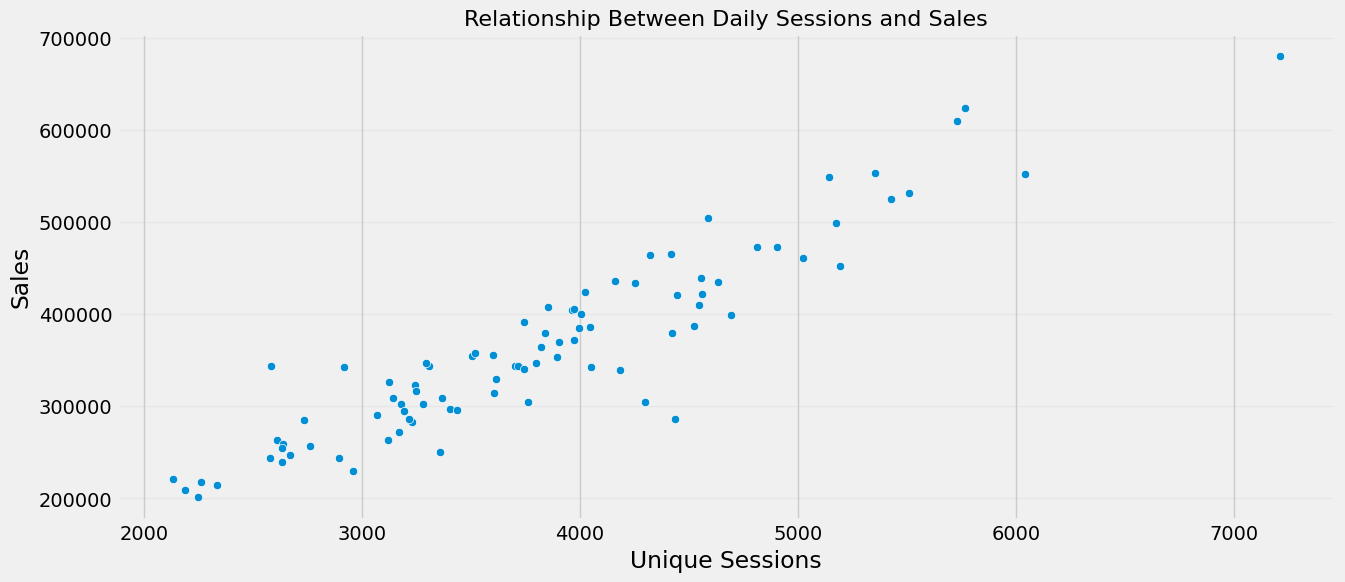

In [ ]:
plt.figure(figsize=(14,6))
sns.scatterplot(data=daily_data, x='ga_session_id', y='price')
plt.title('Relationship Between Daily Sessions and Sales', fontsize=16)
plt.xlabel('Unique Sessions')
plt.ylabel('Sales')
plt.grid(axis='y', alpha=0.25)
plt.show()

### The scatter plot shows a clear positive relationship between daily unique sessions and daily sales. Days with more website sessions generally generated higher sales, indicating that increased traffic was associated with higher revenue.

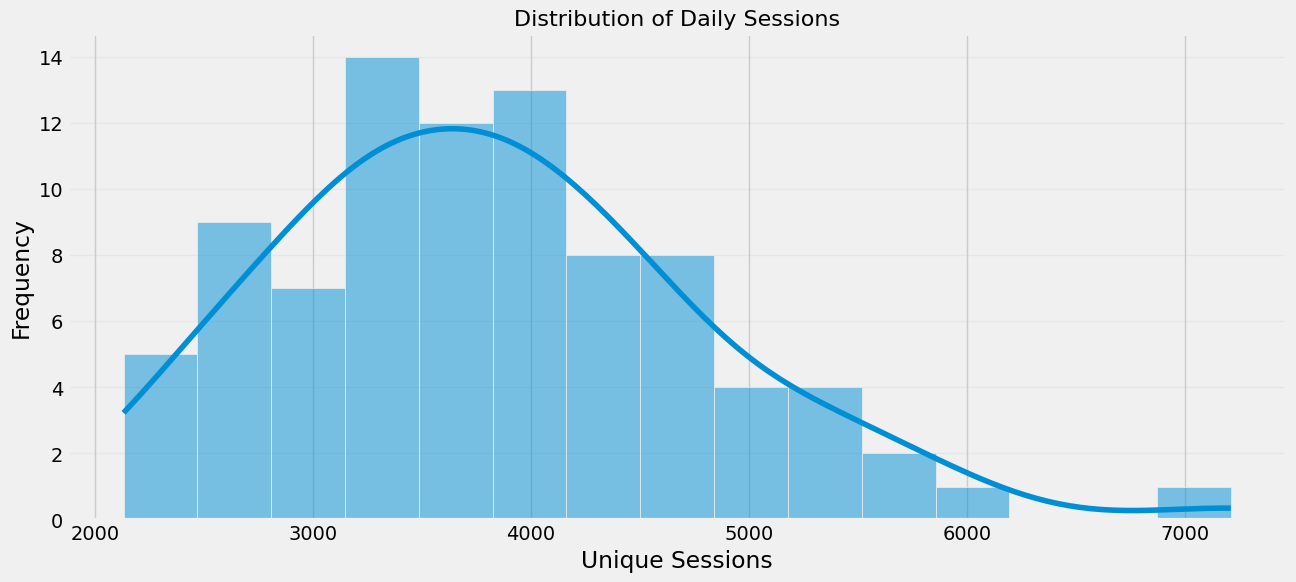

In [ ]:
plt.figure(figsize=(14,6))
sns.histplot(daily_data['ga_session_id'], bins=15, kde=True)
plt.title('Distribution of Daily Sessions', fontsize=16)
plt.xlabel('Unique Sessions')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.25)
plt.show()

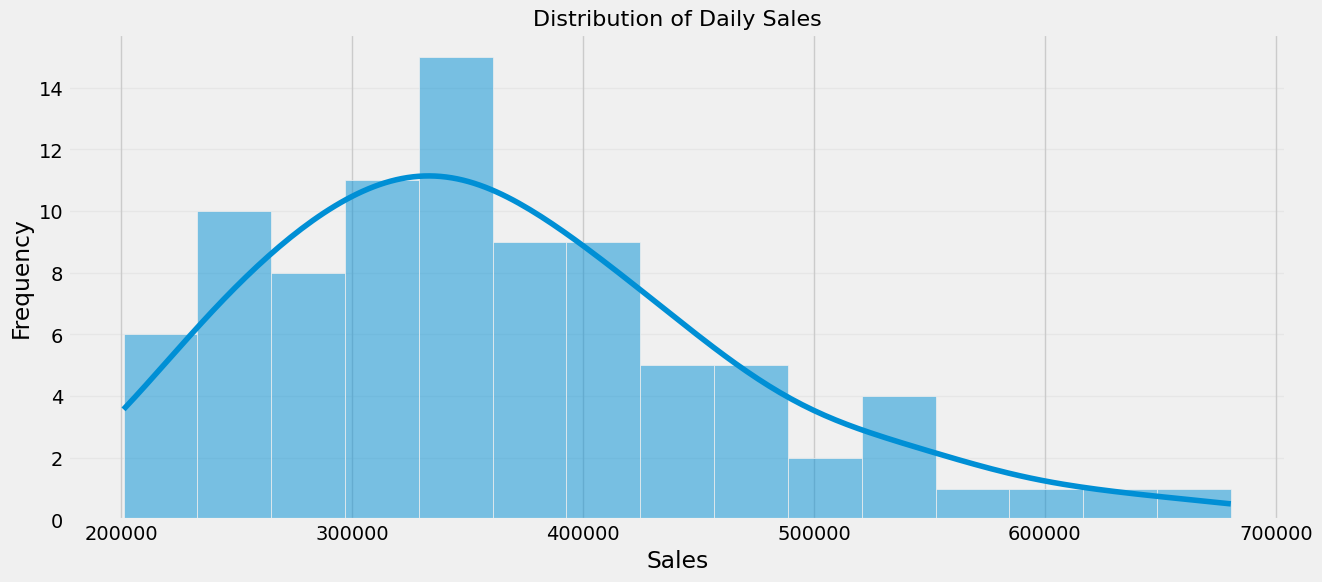

In [ ]:
plt.figure(figsize=(14,6))
sns.histplot(daily_data['price'], bins=15, kde=True)
plt.title('Distribution of Daily Sales', fontsize=16)
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.25)
plt.show()

In [ ]:
print(stats.normaltest(daily_data['ga_session_id']))
print(stats.normaltest(daily_data['price']))

NormaltestResult(statistic=np.float64(8.462957568472412), pvalue=np.float64(0.014530886606437964))
NormaltestResult(statistic=np.float64(9.879636561665645), pvalue=np.float64(0.007155898618108501))


### The D'Agostino–Pearson normality test indicated that both daily sessions and daily sales significantly deviated from a normal distribution (p < 0.05). Therefore, Spearman's rank correlation was selected because it does not require normally distributed data and is appropriate for assessing monotonic relationships.

In [ ]:
print(stats.spearmanr(daily_data['ga_session_id'], daily_data['price']))

SignificanceResult(statistic=np.float64(0.904283047444613), pvalue=np.float64(1.5381769633064087e-33))


### Spearman's rank correlation revealed a very strong positive relationship between daily unique sessions and daily sales (ρ = 0.904, p < 0.001). This indicates that days with higher website traffic were consistently associated with higher sales, and the relationship was statistically significant.

In [ ]:
top_continents = df.groupby('continent')['price'].sum().nlargest(3).index

In [ ]:
continent_sales = df[df['continent'].isin(top_continents)].pivot_table(index='order_date', columns='continent', values='price', aggfunc='sum')
continent_sales = continent_sales[(continent_sales > 0).any(axis=1)]
continent_sales

continent,Americas,Asia,Europe
order_date,,,
2020-11-01,132002.5,63823.0,46908.0
2020-11-02,193861.0,79370.0,75710.8
2020-11-03,294529.8,126737.8,67692.0
2020-11-04,200009.5,66602.0,65915.0
2020-11-05,182988.2,117608.4,86540.0
...,...,...,...
2021-01-23,155342.9,68543.0,62883.6
2021-01-24,116989.4,74801.2,47534.8
2021-01-25,182548.1,66215.2,55621.0


In [ ]:
print(stats.normaltest(continent_sales['Americas']))
print(stats.normaltest(continent_sales['Asia']))
print(stats.normaltest(continent_sales['Europe']))

NormaltestResult(statistic=np.float64(5.696344261308411), pvalue=np.float64(0.05795014942671144))
NormaltestResult(statistic=np.float64(8.044903902137744), pvalue=np.float64(0.017908999071036248))
NormaltestResult(statistic=np.float64(12.01696460216043), pvalue=np.float64(0.002457815575210439))


In [ ]:
continent_sales.corr(method='spearman')

continent,Americas,Asia,Europe
continent,,,
Americas,1.000000,0.668539,0.625885
Asia,0.668539,1.000000,0.608221
Europe,0.625885,0.608221,1.000000


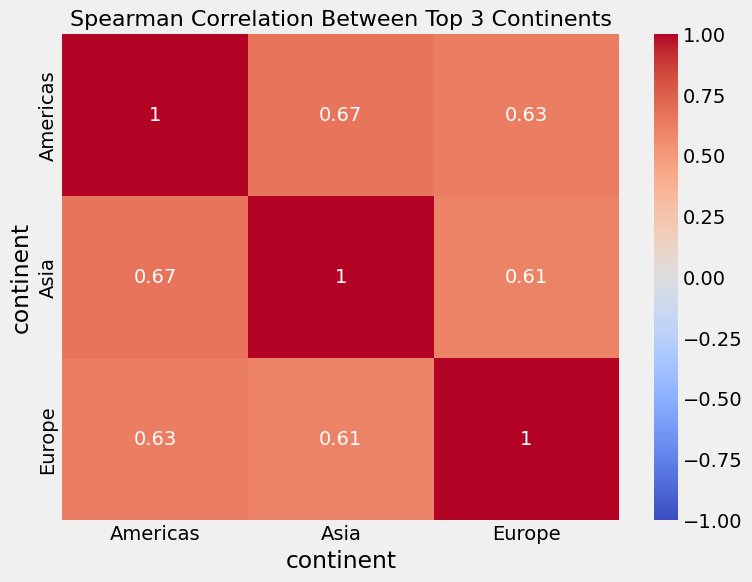

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(continent_sales.corr(method='spearman'), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Spearman Correlation Between Top 3 Continents', fontsize=16)
plt.show()

In [ ]:
print(stats.spearmanr(continent_sales['Americas'], continent_sales['Asia']))
print(stats.spearmanr(continent_sales['Americas'], continent_sales['Europe']))
print(stats.spearmanr(continent_sales['Asia'], continent_sales['Europe']))

SignificanceResult(statistic=np.float64(0.6685393258426968), pvalue=np.float64(1.1001059722381636e-12))
SignificanceResult(statistic=np.float64(0.6258849635447854), pvalue=np.float64(7.009052955139405e-11))
SignificanceResult(statistic=np.float64(0.6082209150787222), pvalue=np.float64(3.2731384105062476e-10))


### Spearman's correlation analysis showed moderate positive relationships between daily sales across the top three continents. The strongest correlation was observed between the Americas and Asia (ρ = 0.669). The correlations between the Americas and Europe (ρ = 0.626) and between Asia and Europe (ρ = 0.608) were also positive and statistically significant (p < 0.001). These results suggest that sales trends across the leading markets tended to move in the same direction during the observation period.

In [ ]:
traffic_sales = df.pivot_table(index='order_date', columns='traffic_channel', values='price', aggfunc='sum')

In [ ]:
traffic_sales = traffic_sales[(traffic_sales > 0).any(axis=1)]

In [ ]:
traffic_sales

traffic_channel,Direct,Organic Search,Paid Search,Social Search,Undefined
order_date,,,,,
2020-11-01,54669.5,95112.0,64688.0,25078.0,4745.0
2020-11-02,81561.5,127746.5,104780.8,16843.0,24575.0
2020-11-03,102909.5,182521.9,152641.3,27652.5,33254.4
2020-11-04,79683.6,117067.1,100332.0,24257.4,17847.0
2020-11-05,83367.6,122938.4,107648.0,41693.2,35629.4
...,...,...,...,...,...
2021-01-23,88714.4,90686.0,73075.1,23095.0,15035.0
2021-01-24,58644.2,93413.6,59018.0,20596.1,12146.5
2021-01-25,67844.0,136178.6,66775.7,23809.0,10482.0


In [ ]:
print(stats.normaltest(traffic_sales['Direct']))
print(stats.normaltest(traffic_sales['Organic Search']))
print(stats.normaltest(traffic_sales['Paid Search']))
print(stats.normaltest(traffic_sales['Social Search']))
print(stats.normaltest(traffic_sales['Undefined']))

NormaltestResult(statistic=np.float64(5.599129662389636), pvalue=np.float64(0.060836531026207154))
NormaltestResult(statistic=np.float64(18.903620942876042), pvalue=np.float64(7.854722894820324e-05))
NormaltestResult(statistic=np.float64(11.333898298934578), pvalue=np.float64(0.00345840025987651))
NormaltestResult(statistic=np.float64(4.33576817240561), pvalue=np.float64(0.11441946267795625))
NormaltestResult(statistic=np.float64(6.440119639278191), pvalue=np.float64(0.03995266823497466))


In [ ]:
traffic_sales.corr(method='spearman')

traffic_channel,Direct,Organic Search,Paid Search,Social Search,Undefined
traffic_channel,,,,,
Direct,1.000000,0.748248,0.690782,0.393681,0.493748
Organic Search,0.748248,1.000000,0.763922,0.384770,0.456905
Paid Search,0.690782,0.763922,1.000000,0.420397,0.493255
Social Search,0.393681,0.384770,0.420397,1.000000,0.385897
Undefined,0.493748,0.456905,0.493255,0.385897,1.000000


In [ ]:
channels = traffic_sales.columns

for i in range(len(channels)):
    for j in range(i + 1, len(channels)):
        print(f'{channels[i]} - {channels[j]}')
        print(stats.spearmanr(traffic_sales[channels[i]], traffic_sales[channels[j]]))
        print()

Direct - Organic Search
SignificanceResult(statistic=np.float64(0.7482476841252511), pvalue=np.float64(5.362547239818307e-17))

Direct - Paid Search
SignificanceResult(statistic=np.float64(0.6907822901623755), pvalue=np.float64(9.505458925584083e-14))

Direct - Social Search
SignificanceResult(statistic=np.float64(0.3936810961220106), pvalue=np.float64(0.00014782706768003086))

Direct - Undefined
SignificanceResult(statistic=np.float64(0.49374801873833263), pvalue=np.float64(1.0172911287944853e-06))

Organic Search - Paid Search
SignificanceResult(statistic=np.float64(0.7639216653164737), pvalue=np.float64(4.8634931780185696e-18))

Organic Search - Social Search
SignificanceResult(statistic=np.float64(0.3847698214222818), pvalue=np.float64(0.00021439393779222672))

Organic Search - Undefined
SignificanceResult(statistic=np.float64(0.45690535733154874), pvalue=np.float64(7.651394403515162e-06))

Paid Search - Social Search
SignificanceResult(statistic=np.float64(0.4203973090063753), pva

### Spearman's correlation analysis revealed statistically significant positive relationships between sales across all traffic channels (p < 0.05). The strongest correlations were observed between Organic Search, Paid Search, and Direct traffic, suggesting that these acquisition channels tended to follow similar daily sales patterns. In contrast, Social Search showed weaker positive correlations with the other channels, indicating less synchronized sales patterns.

In [ ]:
top_categories = df.groupby('category')['price'].sum().nlargest(5).index
top_categories

Index(['Sofas & armchairs', 'Chairs', 'Beds', 'Bookcases & shelving units',
       'Cabinets & cupboards'],
      dtype='object', name='category')

In [ ]:
category_sales = df[df['category'].isin(top_categories)].pivot_table(index='order_date', columns='category', values='price', aggfunc='sum')
category_sales

category,Beds,Bookcases & shelving units,Cabinets & cupboards,Chairs,Sofas & armchairs
order_date,,,,,
2020-11-01,14041.0,36701.0,13591.5,46006.0,75216.0
2020-11-02,79683.5,40979.0,21623.0,58834.0,79977.5
2020-11-03,66219.5,64360.1,33555.5,61204.0,175594.0
2020-11-04,48939.0,35719.8,19266.0,44113.0,86861.5
2020-11-05,23449.0,40998.8,29235.0,90388.4,137288.0
...,...,...,...,...,...
2021-01-23,37116.0,29862.7,26068.0,57493.0,76898.0
2021-01-24,23294.0,25396.0,23664.5,54288.0,57837.0
2021-01-25,47303.5,25919.6,33028.0,51424.2,84544.0


In [ ]:
for category in category_sales.columns:
    print(category)
    print(stats.normaltest(category_sales[category]))
    print()

Beds
NormaltestResult(statistic=np.float64(21.499314465939843), pvalue=np.float64(2.1452760355452934e-05))

Bookcases & shelving units
NormaltestResult(statistic=np.float64(8.365287045079926), pvalue=np.float64(0.015258119024676019))

Cabinets & cupboards
NormaltestResult(statistic=np.float64(14.67194731405992), pvalue=np.float64(0.0006516690890353964))

Chairs
NormaltestResult(statistic=np.float64(13.531715863123406), pvalue=np.float64(0.001152458339643346))

Sofas & armchairs
NormaltestResult(statistic=np.float64(8.38732803725361), pvalue=np.float64(0.015090890148769022))



### The D'Agostino–Pearson normality test showed that daily sales for all top five product categories significantly deviated from a normal distribution (p < 0.05). Therefore, Spearman's rank correlation was used to analyze the relationships between category sales.

In [ ]:
category_sales.corr(method='spearman')

category,Beds,Bookcases & shelving units,Cabinets & cupboards,Chairs,Sofas & armchairs
category,,,,,
Beds,1.000000,0.542742,0.440368,0.534941,0.521715
Bookcases & shelving units,0.542742,1.000000,0.528706,0.636751,0.625603
Cabinets & cupboards,0.440368,0.528706,1.000000,0.526822,0.631204
Chairs,0.534941,0.636751,0.526822,1.000000,0.583319
Sofas & armchairs,0.521715,0.625603,0.631204,0.583319,1.000000


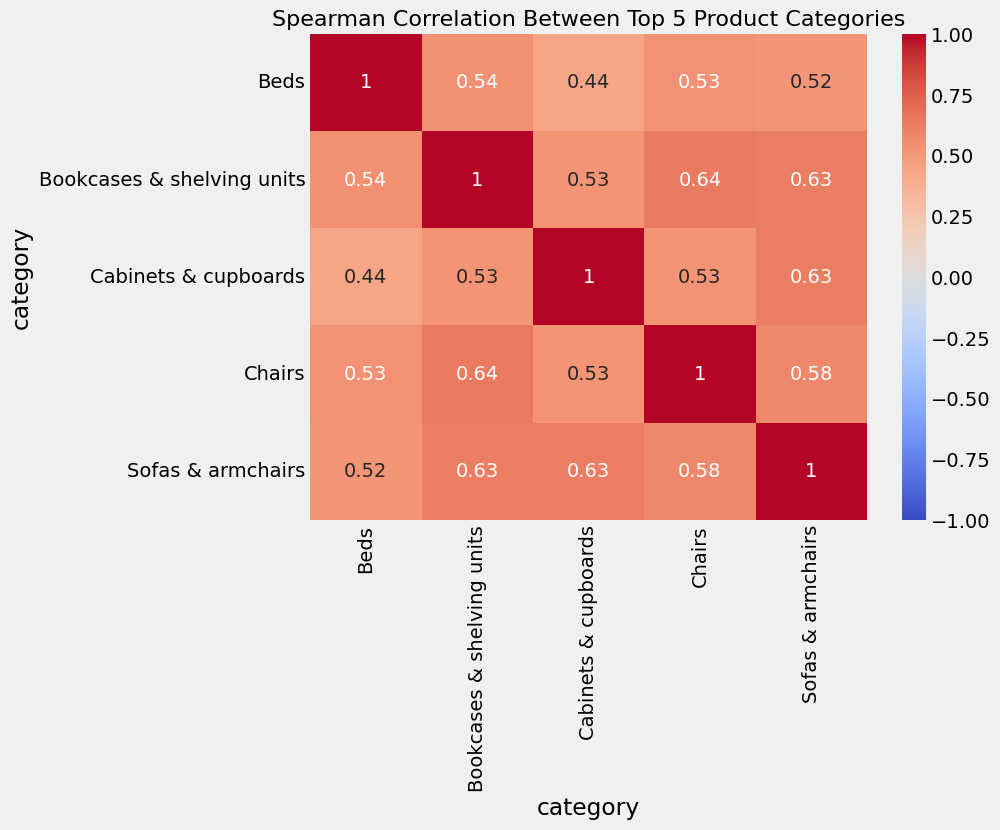

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(category_sales.corr(method='spearman'), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Spearman Correlation Between Top 5 Product Categories', fontsize=16)
plt.show()

In [ ]:
categories = category_sales.columns

for i in range(len(categories)):
    for j in range(i + 1, len(categories)):
        print(f'{categories[i]} — {categories[j]}')
        print(stats.spearmanr(category_sales[categories[i]], category_sales[categories[j]]))
        print()

Beds — Bookcases & shelving units
SignificanceResult(statistic=np.float64(0.5427424183720194), pvalue=np.float64(4.690831718453576e-08))

Beds — Cabinets & cupboards
SignificanceResult(statistic=np.float64(0.4403684266140679), pvalue=np.float64(1.7587830397743514e-05))

Beds — Chairs
SignificanceResult(statistic=np.float64(0.5349406502060513), pvalue=np.float64(7.913415552119658e-08))

Beds — Sofas & armchairs
SignificanceResult(statistic=np.float64(0.521714627875031), pvalue=np.float64(1.864367723360297e-07))

Bookcases & shelving units — Cabinets & cupboards
SignificanceResult(statistic=np.float64(0.5287062801592055), pvalue=np.float64(1.1906129581027331e-07))

Bookcases & shelving units — Chairs
SignificanceResult(statistic=np.float64(0.6367510830897116), pvalue=np.float64(2.5854375788053062e-11))

Bookcases & shelving units — Sofas & armchairs
SignificanceResult(statistic=np.float64(0.6256031841076398), pvalue=np.float64(7.188990897333014e-11))

Cabinets & cupboards — Chairs
Signif

### Spearman's correlation analysis revealed statistically significant moderate positive relationships between daily sales across all top five product categories (p < 0.05). This indicates that the leading product categories generally followed similar daily sales patterns throughout the observation period, with increases and decreases in sales tending to occur at the same time.

In [ ]:
device_sales = df.pivot_table(index='order_date', columns='device', values='price', aggfunc='sum')

In [ ]:
device_sales = device_sales[(device_sales > 0).any(axis=1)]
device_sales

device,desktop,mobile,tablet
order_date,,,
2020-11-01,144445.0,99698.5,149.0
2020-11-02,206727.3,137269.5,11510.0
2020-11-03,304473.8,180602.8,13903.0
2020-11-04,212227.7,118324.4,8635.0
2020-11-05,249682.0,138256.0,3338.6
...,...,...,...
2021-01-23,174769.3,115462.2,374.0
2021-01-24,147218.2,93233.2,3367.0
2021-01-25,189441.7,107902.6,7745.0


In [ ]:
for device in device_sales.columns:
    print(device)
    print(stats.normaltest(device_sales[device]))
    print()

desktop
NormaltestResult(statistic=np.float64(7.266664983072412), pvalue=np.float64(0.02642796652309989))

mobile
NormaltestResult(statistic=np.float64(7.148346565175033), pvalue=np.float64(0.028038596190901287))

tablet
NormaltestResult(statistic=np.float64(19.14540105530211), pvalue=np.float64(6.960316429483859e-05))



### The D'Agostino–Pearson normality test showed that daily sales for Desktop, Mobile, and Tablet devices significantly deviated from a normal distribution (p < 0.05). Therefore, Spearman's rank correlation was used to evaluate the relationships between device types.

In [ ]:
device_sales.corr(method='spearman')

device,desktop,mobile,tablet
device,,,
desktop,1.000000,0.770209,0.390275
mobile,0.770209,1.000000,0.401432
tablet,0.390275,0.401432,1.000000


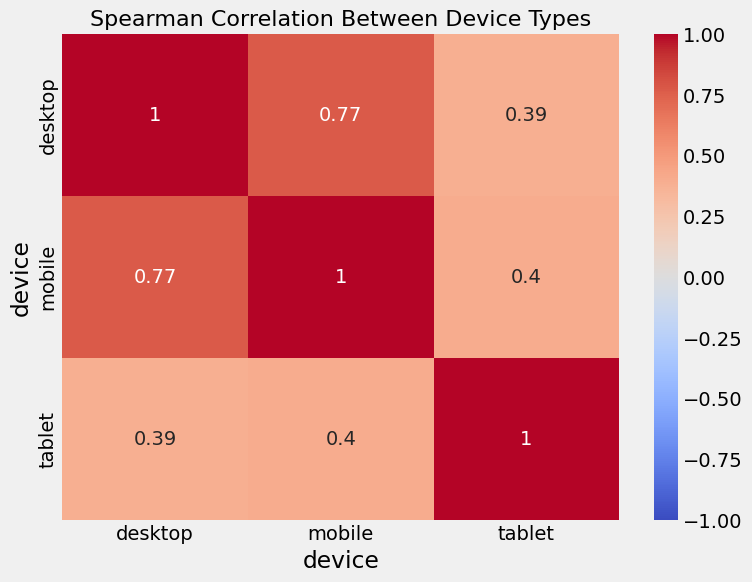

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(device_sales.corr(method='spearman'), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Spearman Correlation Between Device Types', fontsize=16)
plt.show()

In [ ]:
devices = device_sales.columns

for i in range(len(devices)):
    for j in range(i + 1, len(devices)):
        print(f'{devices[i]} — {devices[j]}')
        print(stats.spearmanr(device_sales[devices[i]], device_sales[devices[j]]))
        print()

desktop — mobile
SignificanceResult(statistic=np.float64(0.7702088690077843), pvalue=np.float64(1.7614974818574937e-18))

desktop — tablet
SignificanceResult(statistic=np.float64(0.3902750443622254), pvalue=np.float64(0.0001706113882612224))

mobile — tablet
SignificanceResult(statistic=np.float64(0.4014317980728127), pvalue=np.float64(0.00010606064101142727))



### Spearman's correlation analysis revealed statistically significant positive relationships between daily sales across all device types (p < 0.05). The strongest correlation was observed between Desktop and Mobile sales (ρ = 0.770), indicating that these devices followed very similar daily sales patterns. Tablet sales showed weaker but still statistically significant positive correlations with both Desktop (ρ = 0.390) and Mobile (ρ = 0.401), suggesting that purchasing patterns on tablets were more independent.

# **Statistical Analysis of Differences Between Groups**

### This section compares key business metrics across different customer and traffic groups using statistical hypothesis testing. Data distributions are first evaluated to select the appropriate statistical test. Depending on the normality of the data, either parametric or non-parametric methods are applied to determine whether the observed differences are statistically significant.

In [ ]:
registered_vs_guest = df.assign(is_registered=df['user_id'].notna().astype(int)).pivot_table(values='price', index='order_date', columns='is_registered', aggfunc='sum', fill_value=0)

In [ ]:
guest_sales, registered_sales = registered_vs_guest[0], registered_vs_guest[1]

In [ ]:
###registered_vs_guest.head()

In [ ]:
registered_normality, guest_normality = stats.normaltest(registered_sales), stats.normaltest(guest_sales)

In [ ]:
print(f'Registered p-value: {registered_normality.pvalue:.4f}')
print(f'Guest p-value: {guest_normality.pvalue:.4f}')

Registered p-value: 0.2572
Guest p-value: 0.0264


In [ ]:
comparison = pd.DataFrame({'Registered': registered_sales, 'Guest': guest_sales})

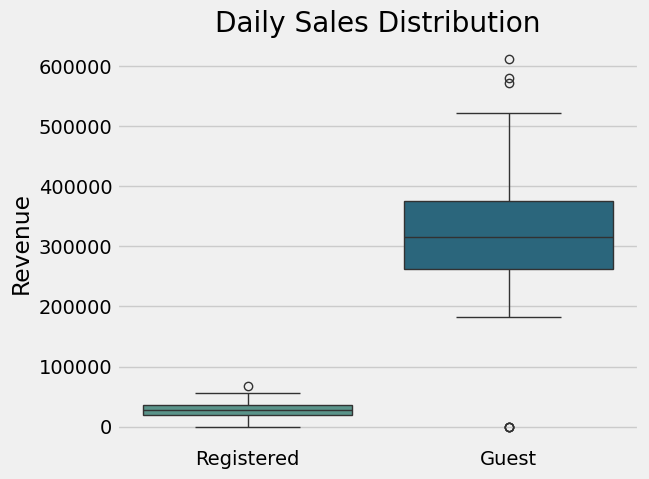

In [ ]:
plt.figure(figsize=(6,5))
sns.boxplot(data=comparison, palette='crest')
plt.title('Daily Sales Distribution')
plt.ylabel('Revenue')
plt.show()

### Statistical Observation: The daily sales distribution of registered users is approximately normal, whereas the distribution for guest users is not. Therefore, the non-parametric Mann–Whitney U test was selected to compare the two groups.

In [ ]:
statistic, p_value = stats.mannwhitneyu(registered_sales, guest_sales, alternative='two-sided')

In [ ]:
print(f'Statistic: {statistic:.4f}')
print(f'p-value: {"< 0.001" if p_value < 0.001 else f"{p_value:.4f}"}')

Statistic: 360.0000
p-value: < 0.001


## Statistical Conclusion

### The Mann–Whitney U test revealed a statistically significant difference in daily sales between registered and guest users (p < 0.001). Therefore, the null hypothesis was rejected, indicating that the distributions of daily sales differ significantly between the two groups.

## Business Conclusion

#### Daily sales differ significantly between registered and guest users. This suggests that customer registration status is associated with different purchasing behavior and should be considered when developing customer retention and marketing strategies.

In [ ]:
traffic_registered = df.assign(is_registered=df['user_id'].notna().astype(int)).pivot_table(values='ga_session_id', index='traffic_channel', columns='is_registered', aggfunc='count', fill_value=0)
traffic_registered

is_registered,0,1
traffic_channel,,
Direct,74868,6514
Organic Search,114390,10035
Paid Search,86874,7467
Social Search,25702,2212
Undefined,19766,1717


### Statistical Observation: The contingency table summarizes the number of sessions by traffic channel for registered and guest users. A Chi-square test of independence is applied to determine whether traffic channel distribution differs significantly between the two groups.

In [ ]:
chi2, p_value, dof, expected = stats.chi2_contingency(traffic_registered)

In [ ]:
print(f'Chi-square: {chi2:.4f}')
print(f'Degrees of freedom: {dof}')
print(f'p-value: {"< 0.001" if p_value < 0.001 else f"{p_value:.4f}"}')

Chi-square: 1.8531
Degrees of freedom: 4
p-value: 0.7628


## Statistical Conclusion

### The Chi-square test did not reveal a statistically significant association between customer registration status and traffic channel distribution (χ² = 1.85, p = 0.763). Therefore, the null hypothesis could not be rejected, indicating that the observed differences in traffic channel distribution are likely due to random variation.

## Business Conclusion

### The distribution of traffic channels is similar for registered and guest users. This suggests that customer registration status is not associated with a specific acquisition channel, indicating that marketing channels attract both user groups in similar proportions.

In [ ]:
df['purchase'] = df['price'].notna().astype(int)

In [ ]:
conversion = df.assign(is_registered=df['user_id'].notna().astype(int)).pivot_table(values='purchase', index='traffic_channel', columns='is_registered', aggfunc='mean')

In [ ]:
conversion

is_registered,0,1
traffic_channel,,
Direct,0.095688,0.097636
Organic Search,0.095332,0.101246
Paid Search,0.095955,0.094549
Social Search,0.096413,0.107595
Undefined,0.094809,0.107746


In [ ]:
for channel in conversion.index:

    guest = (df['traffic_channel'] == channel) & (df['user_id'].isna())
    registered = (df['traffic_channel'] == channel) & (df['user_id'].notna())

    guest_success = (guest & (df['purchase'] == 1)).sum()
    registered_success = (registered & (df['purchase'] == 1)).sum()

    guest_total = guest.sum()
    registered_total = registered.sum()

    statistic, p_value = proportions_ztest([guest_success, registered_success], [guest_total, registered_total])

    print(f'{channel}: p-value = {"< 0.001" if p_value < 0.001 else f"{p_value:.4f}"}')

Direct: p-value = 0.6086
Organic Search: p-value = 0.0536
Paid Search: p-value = 0.6921
Social Search: p-value = 0.0886
Undefined: p-value = 0.0807


## Statistical Observation

### Statistical Observation: Purchase conversion rates were calculated for registered and guest users across each traffic channel. A two-proportion Z-test was then applied separately for every traffic channel to determine whether the observed differences in conversion rates between the two customer groups were statistically significant.

## Statistical Conclusion

### Statistical Conclusion: The two-proportion Z-test did not reveal statistically significant differences in purchase conversion rates between registered and guest users for any traffic channel (all p-values > 0.05). Therefore, the null hypothesis could not be rejected. Although Organic Search produced the lowest p-value (0.054), it remained above the significance threshold of 0.05 and was therefore not considered statistically significant.

## Business Conclusion

### Business Conclusion: Purchase conversion rates are similar for registered and guest users across all traffic channels. This suggests that customer registration status does not meaningfully influence the likelihood of completing a purchase within a specific acquisition channel. Although Organic Search showed the greatest difference in conversion rates, the evidence was insufficient to conclude that the difference was statistically significant.

In [ ]:
europe_organic = ((df['continent'] == 'Europe') & (df['traffic_channel'] == 'Organic Search')).sum()

europe_total = (df['continent'] == 'Europe').sum()

america_organic = ((df['continent'] == 'Americas') & (df['traffic_channel'] == 'Organic Search')).sum()

america_total = (df['continent'] == 'Americas').sum()

In [ ]:
statistic, p_value = proportions_ztest([europe_organic, america_organic], [europe_total, america_total])

In [ ]:
print(f'Z-statistic: {statistic:.4f}')
print(f'p-value: {"< 0.001" if p_value < 0.001 else f"{p_value:.4f}"}')

Z-statistic: 0.2895
p-value: 0.7722


## Statistical Conclusion

### The two-proportion Z-test did not reveal a statistically significant difference in the proportion of Organic Search sessions between Europe and the Americas (Z = 0.29, p = 0.772). Therefore, the null hypothesis could not be rejected.

## Business Conclusion

### The share of Organic Search traffic is similar in Europe and the Americas. This indicates that Organic Search contributes a comparable proportion of website sessions in both regions, suggesting that the effectiveness of organic acquisition is consistent across these markets.

In [ ]:
df['is_weekend'] = df['order_date'].dt.dayofweek.isin([5, 6]).astype(int)

In [ ]:
weekday_prices = df.loc[(df['is_weekend'] == 0) & (df['price'].notna()), 'price']
weekend_prices = df.loc[(df['is_weekend'] == 1) & (df['price'].notna()), 'price']

In [ ]:
print(len(weekday_prices))
print(len(weekend_prices))

25940
7598


In [ ]:
weekday_normality, weekend_normality = stats.normaltest(weekday_prices), stats.normaltest(weekend_prices)

In [ ]:
print('Weekday p-value:', weekday_normality.pvalue)
print('Weekend p-value:', weekend_normality.pvalue)

Weekday p-value: 0.0
Weekend p-value: 0.0


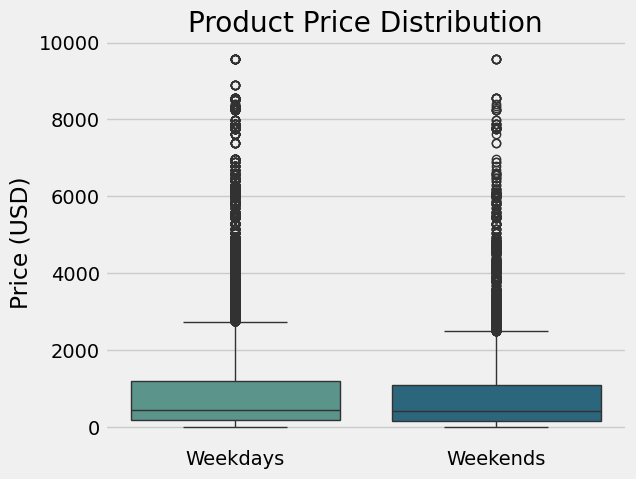

In [ ]:
plt.figure(figsize=(6,5)); sns.boxplot(data=[weekday_prices.tolist(), weekend_prices.tolist()], palette='crest'); plt.xticks([0,1], ['Weekdays', 'Weekends'])
plt.ylabel('Price (USD)')
plt.title('Product Price Distribution')
plt.show()

In [ ]:
statistic, p_value = stats.mannwhitneyu(weekday_prices, weekend_prices, alternative='two-sided')

In [ ]:
print('Statistic:', statistic)
print('p-value:', p_value)

Statistic: 100066776.0
p-value: 0.040462178877090894


## Statistical Conclusion

### The Mann–Whitney U test revealed a statistically significant difference in product prices between weekday and weekend purchases (U = 100066776, p = 0.040). Therefore, the null hypothesis was rejected. However, the difference appears to be relatively small despite being statistically significant.

## Business Conclusion

### Although a statistically significant difference was detected, the observed difference is relatively small and is unlikely to have a substantial business impact. Customers do not consistently purchase much more expensive products on weekends, suggesting that pricing or promotional strategies do not need to differ solely based on the day of the week.

# **General Business Conclusion**

### The analysis of the e-commerce dataset provided valuable insights into customer behavior, marketing performance, and sales trends. Organic Search proved to be the most effective acquisition channel, generating the highest number of orders while maintaining a session-to-purchase conversion rate comparable to Paid Search. This indicates that Organic Search delivers strong performance and should remain a key component of the company's marketing strategy.

### Although registered and guest users demonstrated different purchasing patterns, the majority of total revenue was generated by guest users. This suggests that many customers are willing to complete purchases without creating an account. Therefore, the business should preserve a simple checkout process while encouraging guest users to register through loyalty programs, personalized offers, or other incentives that increase long-term customer retention.

### The geographical analysis showed a consistent distribution of Organic Search traffic across major regions, indicating a stable customer acquisition strategy. In addition, statistical analysis confirmed that while product prices differed slightly between weekdays and weekends, the effect size was too small to have practical business significance.

### Overall, the results suggest that the company should continue investing in Organic Search, maintain a frictionless purchasing experience for guest users, and develop strategies to convert more guests into registered customers. Continuous monitoring of customer behavior and marketing performance will support more informed business decisions and contribute to sustainable long-term revenue growth.